In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from process_data import pre_process_data

con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT id, pid, value,protein_value,comment_nr, analysis,sign,age
                FROM protein_data p
                LEFT JOIN comment_precences c 
                    ON p.id = c.row_id
                WHERE comment_nr BETWEEN 16 AND 27""").df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()


con.close()

def to_severity(label: int) -> int:
    severity = 0
    match label:
        case 20:
            severity = 0 #inga tecken på inflammation
        case 19:
            severity = 1 #inga säkra tecken på inflammation
        case 16:
            severity = 3 #endast en svag markör som tecken på inflammation
        case 17:
            severity = 3 #endast en svag markör som tecken på inflammation
        case 18:
            severity = 3 #endast en svag markör som tecken på inflammation
        case 21:
            severity = 2 #tecken på diskret inflammation
        case 22:
            severity = 3 #tecken på lätt inflammation
        case 23:
            severity = 4 #tecken på lätt-måttlig inflammation
        case 24:
            severity = 5 #tecken på måttlig inflammation
        case 25:
            severity = 6 #tecken på måttlig-kraftig inflammation
        case 26:
            severity = 7 #tecken på kraftig inflammation
        case 27:
            severity = 8 # tecken på mycket kraftig inflammation

    return severity

def to_ordinal(label: int) -> list[int]:
    severity = to_severity(label)
    if severity == 0:
        return [0]*9
    
    new_label = []
    for i in range(9):
        if i <= severity:
            new_label.append(1)
        else:
            new_label.append(0)
    return new_label

def from_ordinal_to_severity(logits: torch.Tensor) -> torch.Tensor:
    probs = torch.sigmoid(logits)

    severity = (probs > 0.5).sum(dim=1)
    return severity

def to_coral(label: int, num_classes: int = 9):
    severity = to_severity(label)
    new_label = []
    for i in range(num_classes-1):
        if severity > i:
            new_label.append(1)
        else:
            new_label.append(0)
    return new_label
    


comment_range = range(16,28,1)

most_frequent = 0
position_weights = []

for i in comment_range:
    no_occurences = (df['comment_nr'] == i).sum()
    print(f"Antal fall med kommentar {i}:{no_occurences}")
    if no_occurences > most_frequent:
        most_frequent=no_occurences

for i in comment_range:
    no_occurences = (df['comment_nr'] == i).sum()
    position_weights.append( most_frequent/no_occurences) 



df['label'] = df['comment_nr'].apply(to_coral)
df = df.set_index('id')



Antal fall med kommentar 16:1233
Antal fall med kommentar 17:8864
Antal fall med kommentar 18:8883
Antal fall med kommentar 19:3468
Antal fall med kommentar 20:78250
Antal fall med kommentar 21:10737
Antal fall med kommentar 22:28598
Antal fall med kommentar 23:7252
Antal fall med kommentar 24:4795
Antal fall med kommentar 25:1564
Antal fall med kommentar 26:5929
Antal fall med kommentar 27:235


In [2]:
valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

train_set = set(train_pids['pid'])
val_set = set(val_pids['pid'])
print(len(train_set & val_set))  # ska vara 0


test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]

id_train = torch.tensor(train_rows.index.to_numpy())
id_val   = torch.tensor(val_rows.index.to_numpy())
id_test  = torch.tensor(test_rows.index.to_numpy())

X_train = torch.tensor(np.array(train_rows['value'].tolist(), dtype=np.float32))
y_train = torch.tensor(np.array(train_rows['label'].tolist(), dtype=np.float32))

X_val = torch.tensor(np.array(val_rows['value'].tolist(), dtype=np.float32))
y_val = torch.tensor(np.array(val_rows['label'].tolist(), dtype=np.float32))

X_test = torch.tensor(np.array(test_rows['value'].tolist(), dtype=np.float32))
y_test = torch.tensor(np.array(test_rows['label'].tolist(), dtype=np.float32))

print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(df):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(df):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(df):.0%})")


0
Träning:    115052 (72%)
Validering:  20128 (13%)
Test:        24628 (15%)


In [3]:
batch_sz = 512

# DataLoaders
train_dataloader = DataLoader(TensorDataset(X_train, y_train, id_train), batch_size=batch_sz, shuffle=True)
val_dataloader   = DataLoader(TensorDataset(X_val,   y_val,id_val),   batch_size=batch_sz)
test_dataloader   = DataLoader(TensorDataset(X_test,   y_test,id_test),   batch_size=batch_sz)

for X, y,_ in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class InflammationNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(300, 256),
            nn.ReLU(),
            #nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.ReLU(),
            #nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            #nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 8)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits
    
def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for X,y,_ in train_dataloader:
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    return total_loss / len(train_dataloader)

def test(
        dataloader: DataLoader,
        model: nn.Module,
        loss_fn: nn.Module)-> tuple[float,float,list[any],list[any]]:
    
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    all_ids = []
    with torch.no_grad():
        for X, y,id in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            loss = loss_fn(pred, y)
            total_loss += loss.item()

            predicted_severity = coral_predict_soft(pred)
            true_severity = y.sum(dim=1)

            all_predictions.append(predicted_severity)
            all_labels.append(true_severity)
            all_ids.append(id)
    
    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)
    all_ids = torch.cat(all_ids)

    mae = torch.mean(torch.abs(all_labels.float() - all_predictions.float())).item()

    return (mae,total_loss/len(dataloader),all_predictions,all_labels,all_ids)


def compute_mae(truth, predictions) -> float:
    truth = truth.detach().float()
    predictions = predictions.detach().float()
    return (truth - predictions).abs().mean().item()

def coral_predict_soft(logits: torch.Tensor) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    return probs.sum(dim=1)

model = InflammationNetwork().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

print(y_train.min(), y_train.max())  
print(y_train.dtype)                


Shape of X: torch.Size([512, 300])
Shape of y: torch.Size([512, 8])
Using mps device
InflammationNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=300, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=8, bias=True)
  )
)
Antal parametrar: 184,520
tensor(0.) tensor(1.)
torch.float32


In [6]:
## KÖR DETTA BLOCKET FÖR ATT TRÄNA! Annars kör nästa block och läs in vikterna!


epochs = 50
accuracies = []
mean_absolute_errors = []
train_losses = []
validation_losses = []
best_val_loss = 10000
no_fails = 0
for t in range(epochs):
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    (mean_absolute_error,avg_loss,_,_,_) = test(val_dataloader, model, loss_fn)
    scheduler.step()
    print(f"Epoch {t:>3} | train loss: {train_loss:.4f} | val loss: {avg_loss:.4f} | val MAE: {mean_absolute_error:.3f}")
    train_losses.append(train_loss)
    mean_absolute_errors.append(mean_absolute_error)
    validation_losses.append(avg_loss)

    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        no_fails = 0
        torch.save(model.state_dict(), "inflammation_model.pth")
    else:
        no_fails += 1
    
    if no_fails == 5:
        break


print("Done!")
print("Saved PyTorch Model State to inflammation_model.pth")


Epoch   0 | train loss: 0.2653 | val loss: 0.1853 | val MAE: 0.817
Epoch   1 | train loss: 0.1902 | val loss: 0.1884 | val MAE: 0.767
Epoch   2 | train loss: 0.1821 | val loss: 0.1742 | val MAE: 0.740
Epoch   3 | train loss: 0.1786 | val loss: 0.1812 | val MAE: 0.756
Epoch   4 | train loss: 0.1771 | val loss: 0.1747 | val MAE: 0.734
Epoch   5 | train loss: 0.1742 | val loss: 0.1704 | val MAE: 0.721
Epoch   6 | train loss: 0.1709 | val loss: 0.1696 | val MAE: 0.755
Epoch   7 | train loss: 0.1684 | val loss: 0.1781 | val MAE: 0.781
Epoch   8 | train loss: 0.1697 | val loss: 0.1722 | val MAE: 0.704
Epoch   9 | train loss: 0.1676 | val loss: 0.1654 | val MAE: 0.695
Epoch  10 | train loss: 0.1629 | val loss: 0.1643 | val MAE: 0.695
Epoch  11 | train loss: 0.1615 | val loss: 0.1643 | val MAE: 0.709
Epoch  12 | train loss: 0.1613 | val loss: 0.1615 | val MAE: 0.690
Epoch  13 | train loss: 0.1615 | val loss: 0.1672 | val MAE: 0.706
Epoch  14 | train loss: 0.1620 | val loss: 0.1625 | val MAE: 0

In [4]:

model.load_state_dict(torch.load("inflammation_model.pth", weights_only=True))

mae,_,all_predictions,all_labels,all_ids = test(val_dataloader,model,loss_fn)

all_predictions = all_predictions.detach().cpu().numpy()
all_labels = all_labels.detach().cpu().numpy()
all_ids = all_ids.numpy()

result_df = pd.DataFrame({
    'severity': all_labels,
    'prediction': all_predictions
}, index=all_ids)
if 'severity' not in df.columns:
    df = df.join(result_df, how='left')

no_bad_predictions = (np.abs(all_predictions - all_labels) > 1 ).sum()
no_very_bad_predictions = (np.abs(all_predictions - all_labels) > 2 ).sum()
no_very_very_bad_predictions = (np.abs(all_predictions - all_labels) > 3 ).sum()

false_negatives = ( (all_predictions < 2) & (all_labels > 4 )).sum()

print(f"mean absolute error of prediction: {mae}")
print(f"% of predictions with error greater than 1 level: {100*(no_bad_predictions/len(all_predictions)):.1f}%")
print(f"% of predictions with error greater than 2 levels: {100*(no_very_bad_predictions/len(all_predictions)):.1f}%")
print(f"% of predictions with error greater than 3 levels: {100*(no_very_very_bad_predictions/len(all_predictions)):.1f}%")
print(f"Number of false negatives: {false_negatives} ({100*(false_negatives/len(all_predictions)):.1f}% of total )")

print(f"The bias is: {np.mean(all_predictions - all_labels)}")

for i in range(10):
    no_predicted = sum(np.abs(all_predictions - i) < 1)
    true_amount = sum(np.abs(all_labels - i < 1))
    print(f"inflammation level: {i} | predicted amount within 1 unit: {no_predicted} | true amount within 1 unit: {true_amount}")


mean absolute error of prediction: 0.6838416457176208
% of predictions with error greater than 1 level: 25.4%
% of predictions with error greater than 2 levels: 7.0%
% of predictions with error greater than 3 levels: 0.4%
Number of false negatives: 8 (0.0% of total )
The bias is: 0.025960609316825867
inflammation level: 0 | predicted amount within 1 unit: 9461 | true amount within 1 unit: 10013
inflammation level: 1 | predicted amount within 1 unit: 12358 | true amount within 1 unit: 10475
inflammation level: 2 | predicted amount within 1 unit: 6807 | true amount within 1 unit: 11878
inflammation level: 3 | predicted amount within 1 unit: 5873 | true amount within 1 unit: 17711
inflammation level: 4 | predicted amount within 1 unit: 2683 | true amount within 1 unit: 18594
inflammation level: 5 | predicted amount within 1 unit: 1222 | true amount within 1 unit: 19210
inflammation level: 6 | predicted amount within 1 unit: 1076 | true amount within 1 unit: 19393
inflammation level: 7 | p

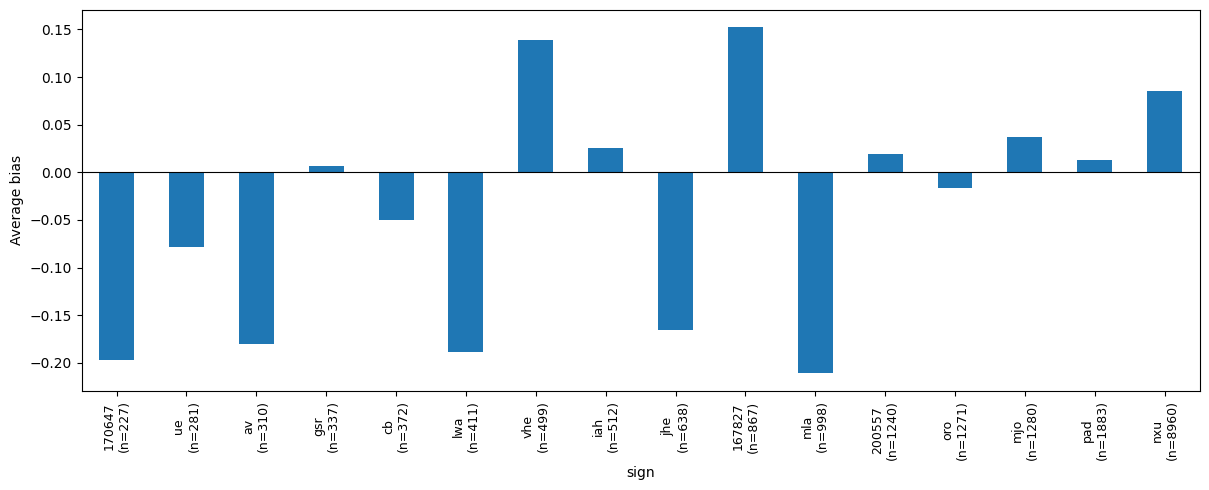

In [5]:
# Analys av hur träningen gick
import matplotlib.pyplot as plt

result = df[df['severity'].notna() & df['prediction'].notna()].copy()
result['error'] = (result['prediction'] - result['severity'])

summary = pd.DataFrame({
    'antal': result.groupby('sign').size(),
    'bias': result.groupby('sign')['error'].mean()
}).sort_values('antal', ascending=False)
summary = summary[summary['antal'] > 50]

summary_sorted = summary.sort_values('antal')
labels = [f"{sign}\n(n={int(antal)})" for sign, antal in zip(summary_sorted.index, summary_sorted['antal'])]
summary_sorted['bias'].plot(kind='bar', figsize=(12,5))
plt.xticks(range(len(labels)), labels, fontsize=9)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.ylabel("Average bias")
plt.show()



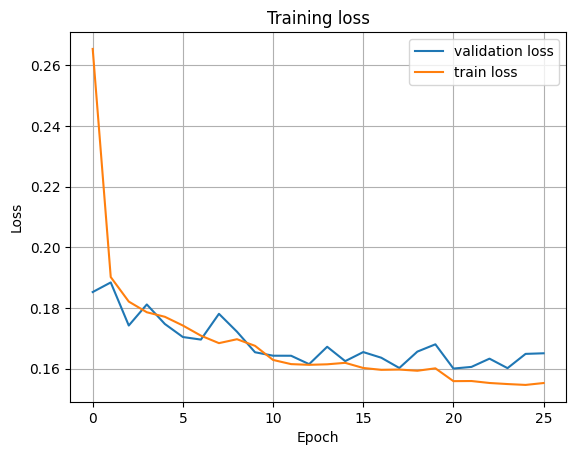

In [9]:


plt.plot(validation_losses, label='validation loss')
plt.plot(train_losses, label = 'train loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.show()